# Pneumonia / COVID / Normal Chest X-ray Classifier

A simple CNN that looks at a chest X-ray image and predicts one of 3 classes:
**COVID**, **Pneumonia**, or **Normal**.

**What this notebook does, step by step:**
1. Collect the images we need from the dataset (ignoring the mask images we don't need)
2. Split them into a train folder and a test folder
3. Build a simple CNN
4. Train it
5. Check how accurate it is
6. Save the model so the Gradio app can use it

Kept intentionally simple — no fancy tricks, just the basics.


## 1. Import libraries

In [1]:
import os
import shutil
import random
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


## 2. Set the paths

`SOURCE_DIR` is your dataset folder (the one with the COVID / Normal / Viral
Pneumonia folders inside it). Change this if your path is different.


In [2]:
SOURCE_DIR = r"D:\Projectsinterns\covid_19_prediction\COVID-19_Radiography_Dataset"

# folder name in the dataset  ->  simple label we want to use
CLASS_MAP = {
    "COVID": "COVID",
    "Normal": "Normal",
    "Viral Pneumonia": "Pneumonia",
}

CLEAN_DIR = "clean_dataset"     # images only, organized by our 3 labels
SPLIT_DIR = "dataset_split"     # train/test split goes here

IMG_SIZE = (150, 150)
BATCH_SIZE = 32
EPOCHS = 10


## 3. Collect just the images we need

The dataset has an `images/` folder and a `masks/` folder inside each class.
We only want the `images/` ones. This copies them into a clean, simple
folder structure: `clean_dataset/COVID/`, `clean_dataset/Normal/`,
`clean_dataset/Pneumonia/`.

This step can take a few minutes the first time since it's copying thousands
of images — that's normal.


In [3]:
if os.path.exists(CLEAN_DIR):
    print("clean_dataset already exists, skipping copy step.")
else:
    for folder_name, label in CLASS_MAP.items():
        src = os.path.join(SOURCE_DIR, folder_name, "images")
        dst = os.path.join(CLEAN_DIR, label)
        os.makedirs(dst, exist_ok=True)

        files = os.listdir(src)
        print(f"Copying {len(files)} images for class '{label}'...")

        for fname in files:
            shutil.copy(os.path.join(src, fname), os.path.join(dst, fname))

    print("Done copying images.")


Copying 3616 images for class 'COVID'...
Copying 10192 images for class 'Normal'...
Copying 1345 images for class 'Pneumonia'...
Done copying images.


## 4. Split into train and test folders

80% of each class goes into `train`, 20% into `test`. This creates real
folders on disk (`dataset_split/train/...` and `dataset_split/test/...`),
like you asked for.


In [4]:
def split_train_test(clean_dir, split_dir, test_ratio=0.2, seed=42):
    random.seed(seed)

    for label in os.listdir(clean_dir):
        src_folder = os.path.join(clean_dir, label)
        files = os.listdir(src_folder)
        random.shuffle(files)

        split_point = int(len(files) * (1 - test_ratio))
        train_files = files[:split_point]
        test_files = files[split_point:]

        train_dst = os.path.join(split_dir, "train", label)
        test_dst = os.path.join(split_dir, "test", label)
        os.makedirs(train_dst, exist_ok=True)
        os.makedirs(test_dst, exist_ok=True)

        for fname in train_files:
            shutil.copy(os.path.join(src_folder, fname), os.path.join(train_dst, fname))
        for fname in test_files:
            shutil.copy(os.path.join(src_folder, fname), os.path.join(test_dst, fname))

        print(f"{label}: {len(train_files)} train, {len(test_files)} test")


if os.path.exists(SPLIT_DIR):
    print("dataset_split already exists, skipping split step.")
else:
    split_train_test(CLEAN_DIR, SPLIT_DIR, test_ratio=0.2)


COVID: 2892 train, 724 test
Normal: 8153 train, 2039 test
Pneumonia: 1076 train, 269 test


## 5. Load the train and test images

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 12121 files belonging to 3 classes.
Found 3032 files belonging to 3 classes.
Classes: ['COVID', 'Normal', 'Pneumonia']


## 6. Look at a few sample images

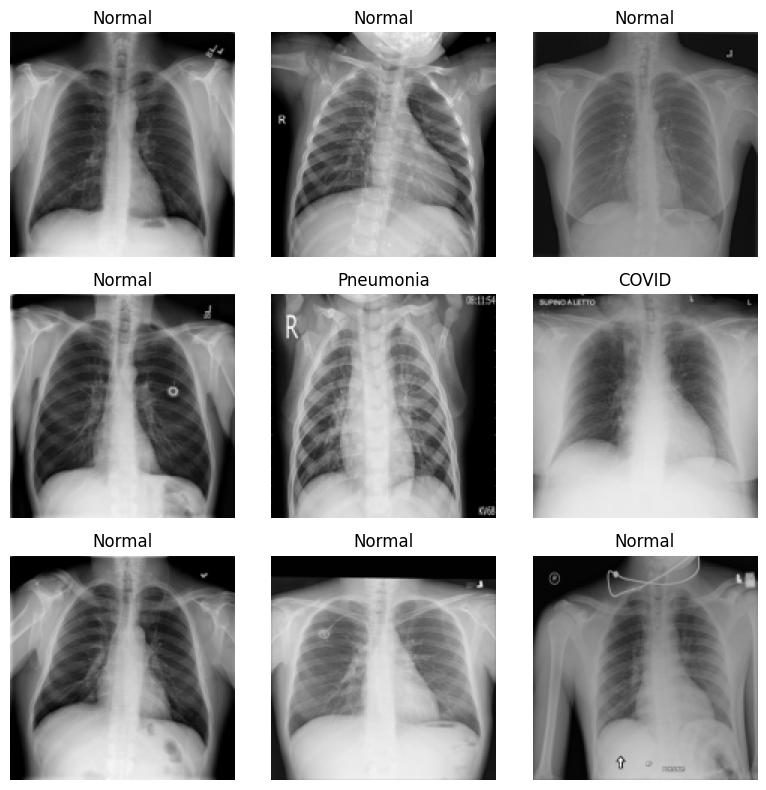

In [6]:
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().argmax()])
        plt.axis("off")
plt.tight_layout()
plt.show()


## 7. Normalize pixel values

Pixel values are 0-255 by default. We scale them to 0-1, which helps the
CNN train better.


In [7]:
normalization = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (normalization(x), y)).prefetch(tf.data.AUTOTUNE)


## 8. Build a simple CNN

Just 3 convolution blocks + a couple of dense layers at the end. Nothing fancy.


In [8]:
model = models.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(3, activation="softmax"),   # 3 classes: COVID, Normal, Pneumonia
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,183,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,240,323 (4.73 MB)

 Trainable params: 1,240,323 (4.73 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the model

In [9]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)


Epoch 1/10


c:\Users\ibrahim laptops\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


379/379 ━━━━━━━━━━━━━━━━━━━━ 151s 391ms/step - accuracy: 0.8033 - loss: 0.4514 - val_accuracy: 0.8786 - val_loss: 0.3021
Epoch 2/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 120s 315ms/step - accuracy: 0.8909 - loss: 0.2818 - val_accuracy: 0.9235 - val_loss: 0.2032
Epoch 3/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 124s 326ms/step - accuracy: 0.9199 - loss: 0.2110 - val_accuracy: 0.9281 - val_loss: 0.1794
Epoch 4/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 128s 337ms/step - accuracy: 0.9367 - loss: 0.1760 - val_accuracy: 0.9456 - val_loss: 0.1563
Epoch 5/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 124s 327ms/step - accuracy: 0.9492 - loss: 0.1357 - val_accuracy: 0.9528 - val_loss: 0.1340
Epoch 6/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 123s 324ms/step - accuracy: 0.9611 - loss: 0.1127 - val_accuracy: 0.9538 - val_loss: 0.1342
Epoch 7/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 124s 325ms/step - accuracy: 0.9632 - loss: 0.1000 - val_accuracy: 0.9581 - val_loss: 0.1248
Epoch 8/10
379/379 ━━━━━━━━━━━━━━━━━━━━ 123s 324ms/step - accuracy: 0.9686 - loss: 0.08

## 10. Check accuracy on the test set

In [10]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2%}")


95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.9545 - loss: 0.1319
Test accuracy: 95.45%


## 11. Plot how training went

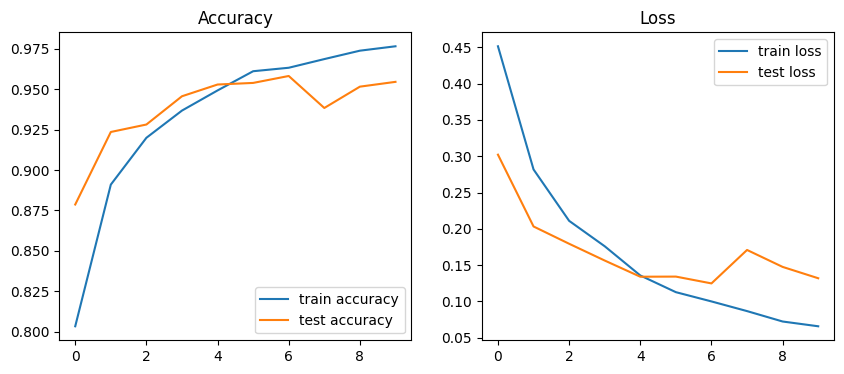

In [11]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="test loss")
plt.legend()
plt.title("Loss")

plt.show()


## 12. Save the model

This saves the trained model to a file. The Gradio app (`app.py`) will load
this file to make predictions.


In [12]:
model.save("pneumonia_covid_model.keras")

with open("class_names.txt", "w") as f:
    f.write("\n".join(class_names))

print("Model saved as pneumonia_covid_model.keras")
print("Classes saved as class_names.txt:", class_names)


Model saved as pneumonia_covid_model.keras
Classes saved as class_names.txt: ['COVID', 'Normal', 'Pneumonia']


## Next step

Run `app.py` (in the same folder as the two saved files above) to launch the
Gradio interface and try the model on new X-ray images.
